In [1]:
import joblib
from analysis_utils import *

# Virtualization Settings
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
# --- 1. Upload Data ---
df = pd.read_csv("../datasets/student_dataset_10000_rows.csv")
print(f"1. Data Uploaded. Size: {df.shape}")

1. Data Uploaded. Size: (10000, 8)


In [3]:
# --- 1.2. General Structure ---
check_general_structure(df)

=== Data Types and Non-Null Information ===
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_hours            10000 non-null  int64  
 1   attendance             10000 non-null  int64  
 2   sleep_hours            10000 non-null  int64  
 3   internet_usage         10000 non-null  int64  
 4   assignments_completed  10000 non-null  int64  
 5   previous_score         10000 non-null  int64  
 6   exam_score             10000 non-null  float64
 7   placement_status       10000 non-null  int64  
dtypes: float64(1), int64(7)
memory usage: 625.1 KB
None

=== Missing Value Summary ===
Empty DataFrame
Columns: [Missing Count, Missing Percentage (%)]
Index: []


,Missing Count,Missing Percentage (%)
study_hours,0,0.0
attendance,0,0.0
sleep_hours,0,0.0
internet_usage,0,0.0
assignments_completed,0,0.0
previous_score,0,0.0
exam_score,0,0.0
placement_status,0,0.0


--- Numerical Column Distributions ---


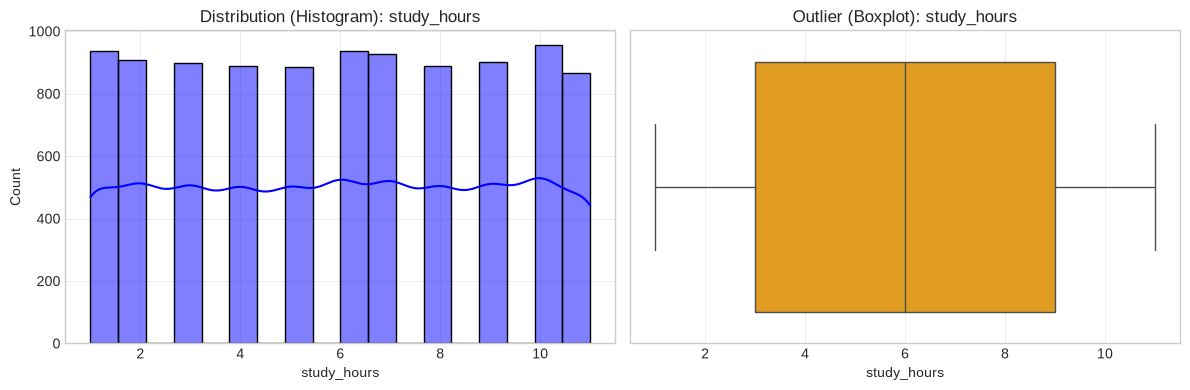

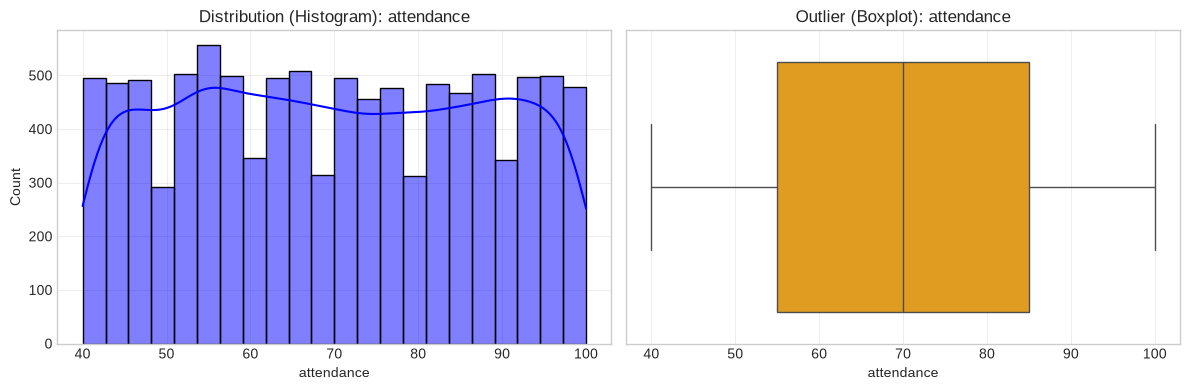

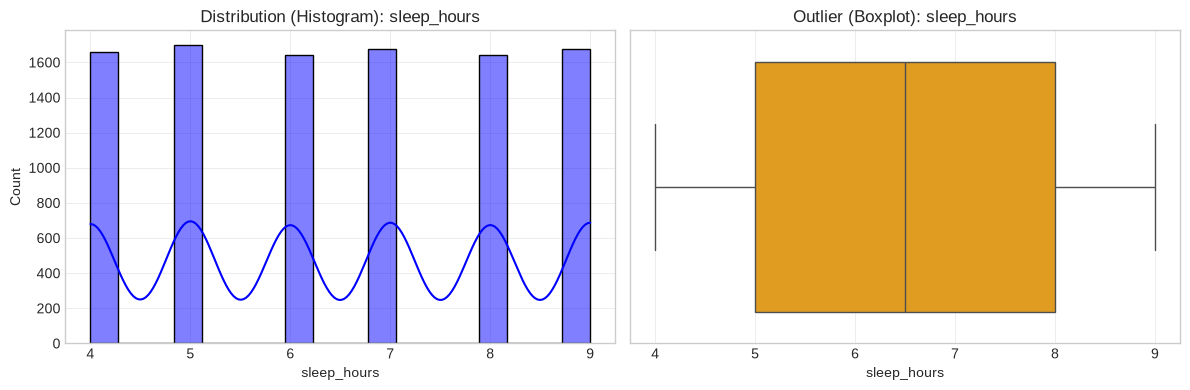

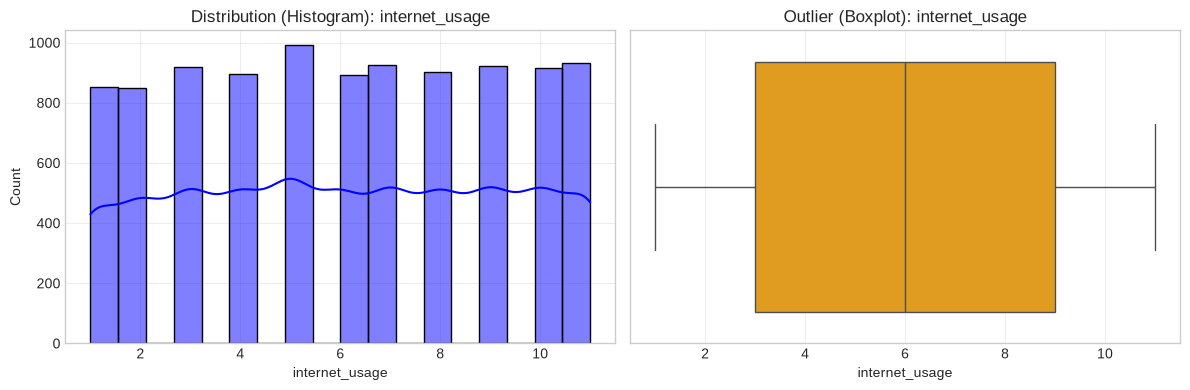

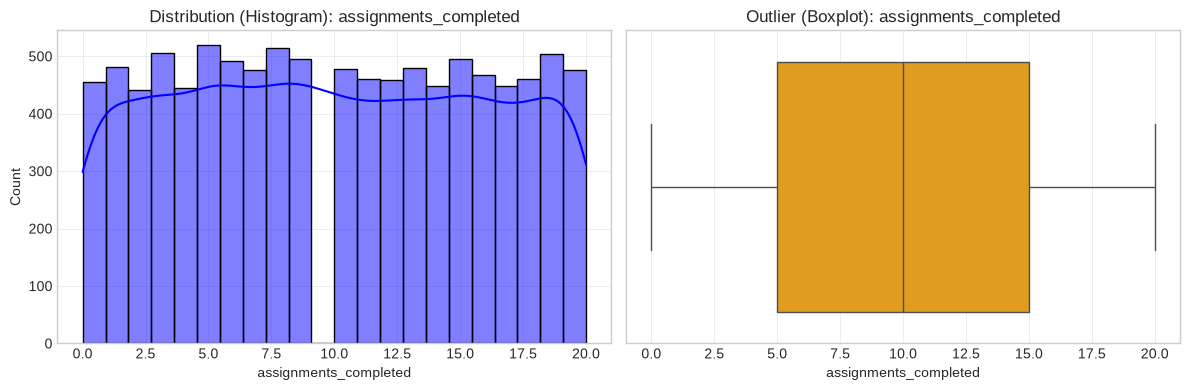

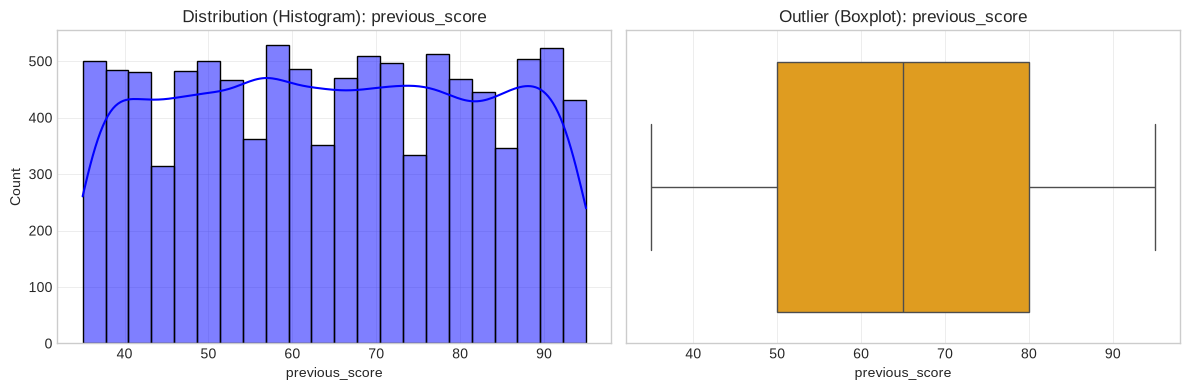

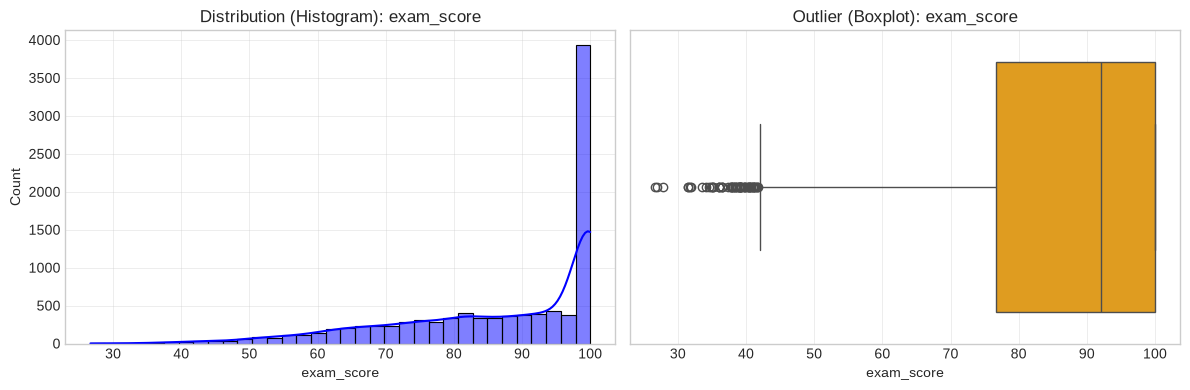

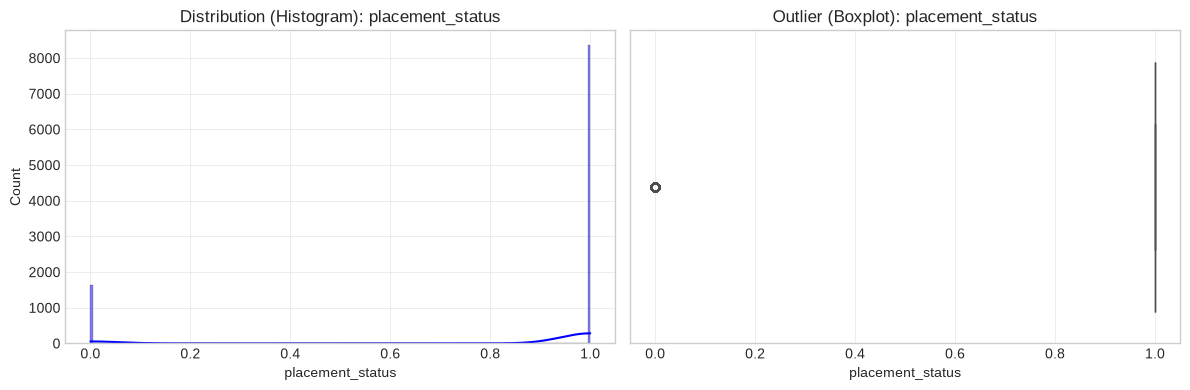

In [4]:
# --- 2. Statistical Distributions ---
numeric_cols = df.select_dtypes(include=["number"])
print("--- Numerical Column Distributions ---")
plot_statistical_distributions(df, numeric_cols)

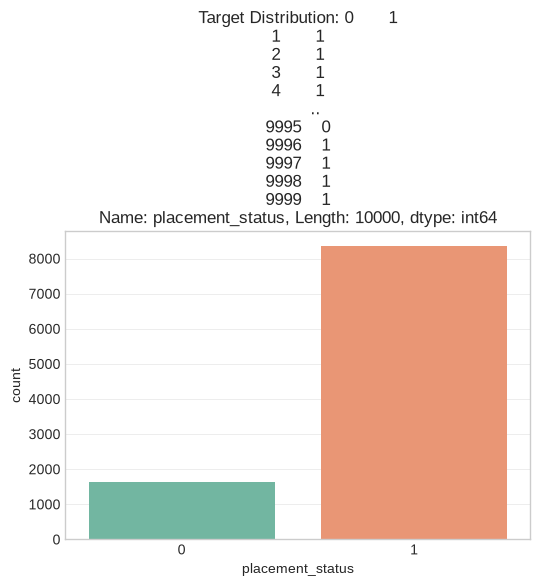

In [5]:
# --- 3. Target Distribution ---
target_column = df["placement_status"]
plot_target_distribution(df, target_column)

=== Correlation Ranking with Target ===
exam_score               0.792392
study_hours              0.400934
assignments_completed    0.280138
previous_score           0.232693
attendance               0.176738
sleep_hours              0.110578
internet_usage          -0.110233
Name: placement_status, dtype: float64
----------------------------------------


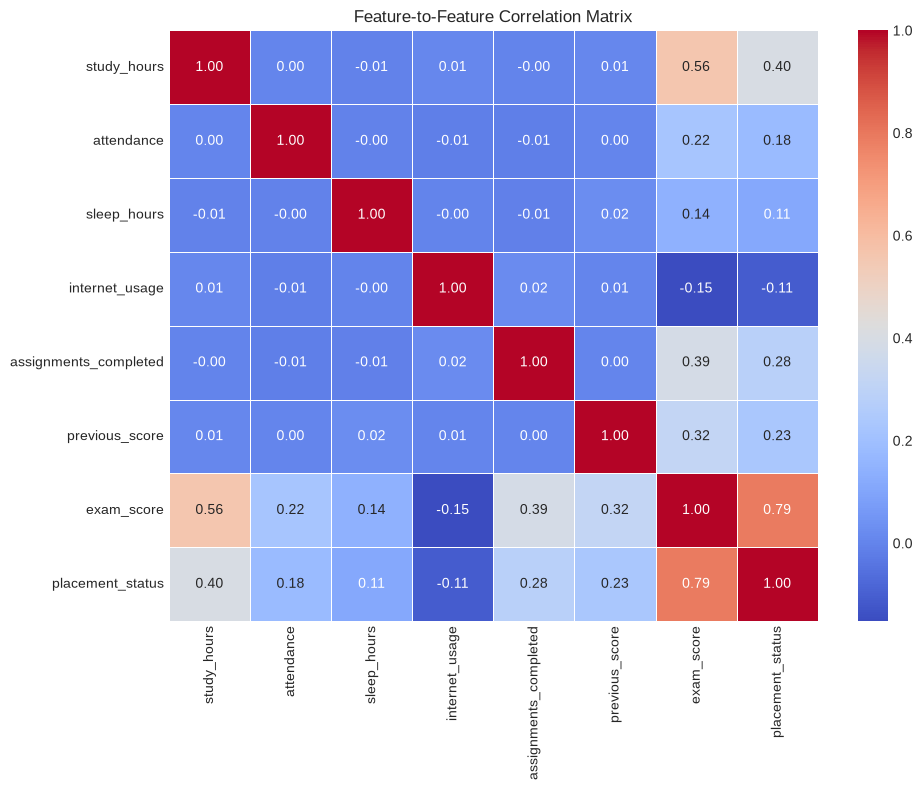

⚠️ Highly correlated (overlapping) features: []


In [6]:
# --- 4. Feature Correlations Analyze
target_corr, to_drop = analyze_feature_correlations(df, target_col="placement_status")

In [7]:
# --- 5. Train - Test Split ---
X = df.drop(columns=["placement_status", "exam_score"])
y = df["placement_status"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\n5. Data is Splitted -> Train: {X_train.shape}, Test: {X_test.shape}")


5. Data is Splitted -> Train: (8000, 6), Test: (2000, 6)


In [8]:
# --- 6. Correlation Filter ---
X_train_corr, X_test_corr = correlation_filter(
    X_train, X_test, corr_threshold=0.95
)

9. Remaining Feature Count After Correlation Filter: 6


In [9]:
# --- 7. Clearing Constant Columns ---
constant_cols = [col for col in X_train_corr.columns if X_train_corr[col].nunique() == 0]

if constant_cols:
    print(f"Detected Constant Columns: {constant_cols}")
    X_train_corr = X_train_corr.drop(columns=constant_cols)
    X_test_corr = X_test_corr.drop(columns=constant_cols)
else:
    print("No Constant Columns Detected.")

No Constant Columns Detected.


In [10]:
# --- 8. Feature Selection ---
selected_features = select_best_features_anova(X_train_corr,y_train)
X_train_selected = X_train_corr[selected_features]
X_test_selected = X_test_corr[selected_features]

=== Top 5 Features (ANOVA / SelectKBest) ===
                 Feature        Score
0            study_hours  1522.569175
4  assignments_completed   744.153195
5         previous_score   449.479781
1             attendance   238.405730
2            sleep_hours   109.202668


In [11]:
# All in Bundle
bundle = {
    "X_train": X_train_selected,
    "X_test": X_test_selected,
    "y_train": y_train,
    "y_test": y_test,
}
# Save to File
joblib.dump(bundle, "../backend/models/student/student_data_bundle.pkl")
print(
    "Processed student datasets are successfully saved to: backend/models/student/"
)

Processed student datasets are successfully saved to: backend/models/student/
